# Tasks 

# Task 1 — Unsupervised Exploration


In [1]:
# IMPORTS

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
# Load dataset
penguins = sns.load_dataset("penguins")

# Create a working copy
penguins_ = penguins.copy()

# First inspect 
print("Dataset shape:")
print(penguins.shape)

print("\nFirst 5 rows of the dataset:")
print(penguins.head(), "\n")

print("\nMissing values:")
print(penguins.isnull().sum())

print("\nColumn types and non-null counts:")
penguins.info()

Dataset shape:
(344, 7)

First 5 rows of the dataset:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female   


Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Column types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column            

In [3]:
# Drop missing values
penguins_data= penguins_.dropna()

print("\nMissing values after dropping:")
print(penguins_data.isnull().sum())


Missing values after dropping:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


## Data Cleaning — Missing Values

The raw dataset contains **344 rows** with missing values in the following columns:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`: 2 missing each
- `sex`: 11 missing

Since the missing values represent less than **4% of the data**, I used `dropna()` to remove them entirely. This avoids introducing imputation bias and keeps the dataset clean for downstream analysis. After dropping, **333 rows** remain — more than enough for robust clustering and classification.


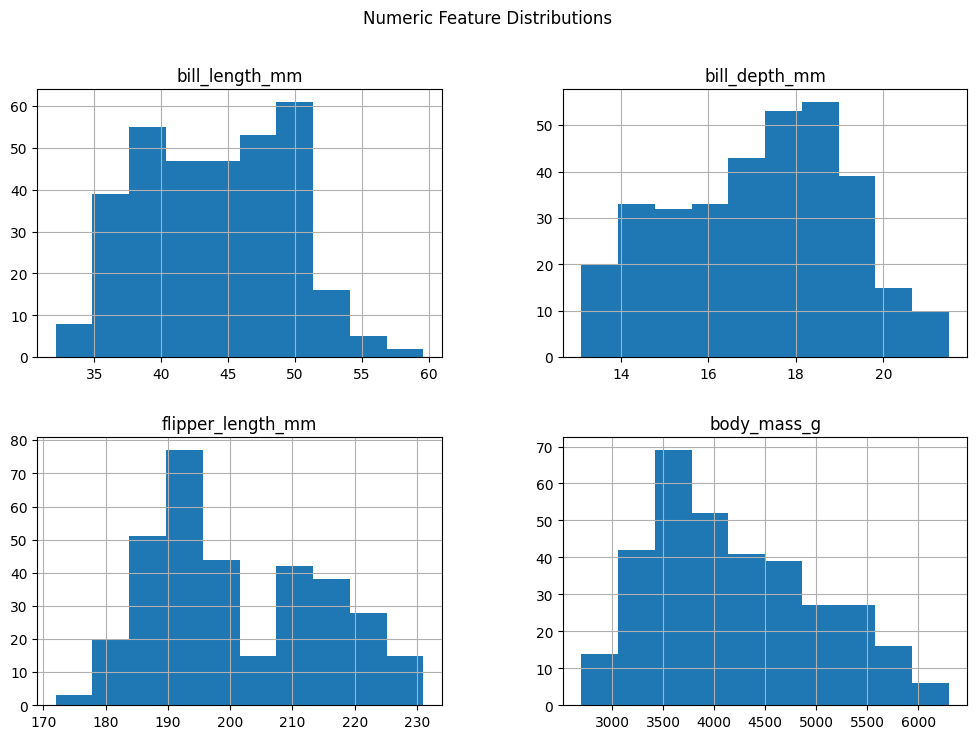

In [4]:
# EXAMINE DISTRIBUTIONS
numeric_cols = penguins_data.select_dtypes(include=np.number).columns

penguins_data[numeric_cols].hist(figsize=(12, 8))
plt.suptitle("Numeric Feature Distributions")
plt.show()

### Exploratory Data Analysis: Numeric Feature Distributions

The figure above visualizes the distribution of four continuous numeric variables in the dataset using histograms. Analyzing these distributions reveals important characteristics about the underlying data:

* **`bill_length_mm`**: The distribution appears to be **bimodal**, with a primary peak around 48-51 mm and a secondary peak near 38-40 mm. This suggests the potential presence of distinct sub-populations within the dataset.
* **`bill_depth_mm`**: This feature displays a multi-peaked but roughly centralized distribution. The majority of the observations are tightly clustered between 17 mm and 19 mm.
* **`flipper_length_mm`**: Similar to bill length, flipper length exhibits a very clear **bimodal distribution**. A large cluster of observations is centered around 190-195 mm, while a distinct second group is centered around 210-215 mm. 
* **`body_mass_g`**: The body mass distribution is **right-skewed** (positive skewness). Most of the records fall between 3500 g and 4000 g, with a long tail indicating a smaller number of significantly heavier individuals (up to 6000+ g).

**Key Takeaway:** The pronounced multimodality observed in features like `bill_length_mm` and `flipper_length_mm` is a strong statistical indicator that the dataset contains multiple distinct groups—likely representing different biological species. This implies that global statistical measures (like overall mean) might be misleading, and species-level analysis will be necessary moving forward.

=== Statistical Summary ===
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000


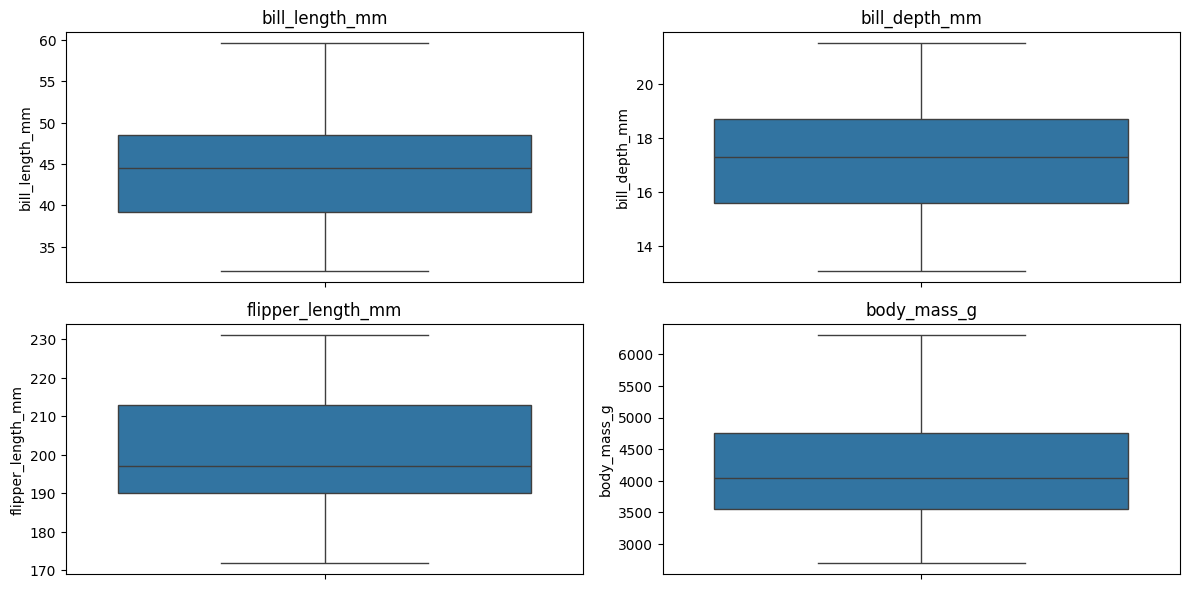


=== IQR-based Outliers ===
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64


In [5]:
# ANOMALY DETECTION

# 1. STATISTICAL SUMMARY
print("=== Statistical Summary ===")
print(penguins_data[numeric_cols].describe())

# 2. BOXPLOTS
plt.figure(figsize=(12, 6))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=penguins_[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# 3. IQR ANOMALY DETECTION
print("\n=== IQR-based Outliers ===")
Q1 = penguins_data[numeric_cols].quantile(0.25)
Q3 = penguins_data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((penguins_data[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (penguins_data[numeric_cols] > (Q3 + 1.5 * IQR)))
print(outlier_mask.sum())


## Statistical Summary and Outlier Analysis

This section provides a detailed quantitative overview of the dataset’s numeric features, including central tendency, dispersion, and a visual assessment of potential outliers.

### 1. Descriptive Statistics
The table below summarizes the key statistical metrics for the dataset (n = 333).

| Metric | bill_length_mm | bill_depth_mm | flipper_length_mm | body_mass_g |
| :--- | :--- | :--- | :--- | :--- |
| **Mean** | 43.99 | 17.16 | 200.97 | 4207.06 |
| **Std Dev** | 5.47 | 1.97 | 14.02 | 805.22 |
| **Min** | 32.10 | 13.10 | 172.00 | 2700.00 |
| **Median (50%)** | 44.50 | 17.30 | 197.00 | 4050.00 |
| **Max** | 59.60 | 21.50 | 231.00 | 6300.00 |

---

### 2. Box Plot Visualizations
The box plots illustrate the distribution and Interquartile Range (IQR) for each feature:

* **Symmetry:** Most features show a relatively symmetric distribution within the IQR (the box), though `body_mass_g` and `flipper_length_mm` show a slightly wider spread in the upper quartiles.
* **Range:** The whiskers extend to the minimum and maximum values, showing the full span of the biological measurements without being disconnected by extreme isolated points.

---

### 3. Outlier Detection (IQR Method)
Using the Interquartile Range (IQR) method, where outliers are defined as values falling outside $1.5 \times IQR$ from the quartiles, the following counts were identified:

* **bill_length_mm:** 0
* **bill_depth_mm:** 0
* **flipper_length_mm:** 0
* **body_mass_g:** 0

**Conclusion:** The analysis confirms that the dataset is **clean and free of statistical outliers**. All data points fall within the expected biological ranges for these species. The consistency between the mean and median across most features suggests that while the distributions may be bimodal (as seen in previous histograms), there are no extreme individual values skewing the overall statistical integrity of the data.

In [6]:
# SELECT FEATURES
X = penguins_data[numeric_cols]

# Actual labels
y = penguins_data["species"]

# SCALE FEATURES
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-0.89604189  0.7807321  -1.42675157 -0.56847478]
 [-0.82278787  0.11958397 -1.06947358 -0.50628618]
 [-0.67627982  0.42472926 -0.42637319 -1.1903608 ]
 ...
 [ 1.17338426 -0.74499437  1.50292796  1.91906927]
 [ 0.22108196 -1.20271231  0.78837197  1.23499466]
 [ 1.08181673 -0.54156417  0.85982757  1.48374906]]


In [7]:
# PCA (2 COMPONENTS)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)


# t-SNE (2 COMPONENTS)
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)
print(X_tsne.shape)


(333, 2)
(333, 2)


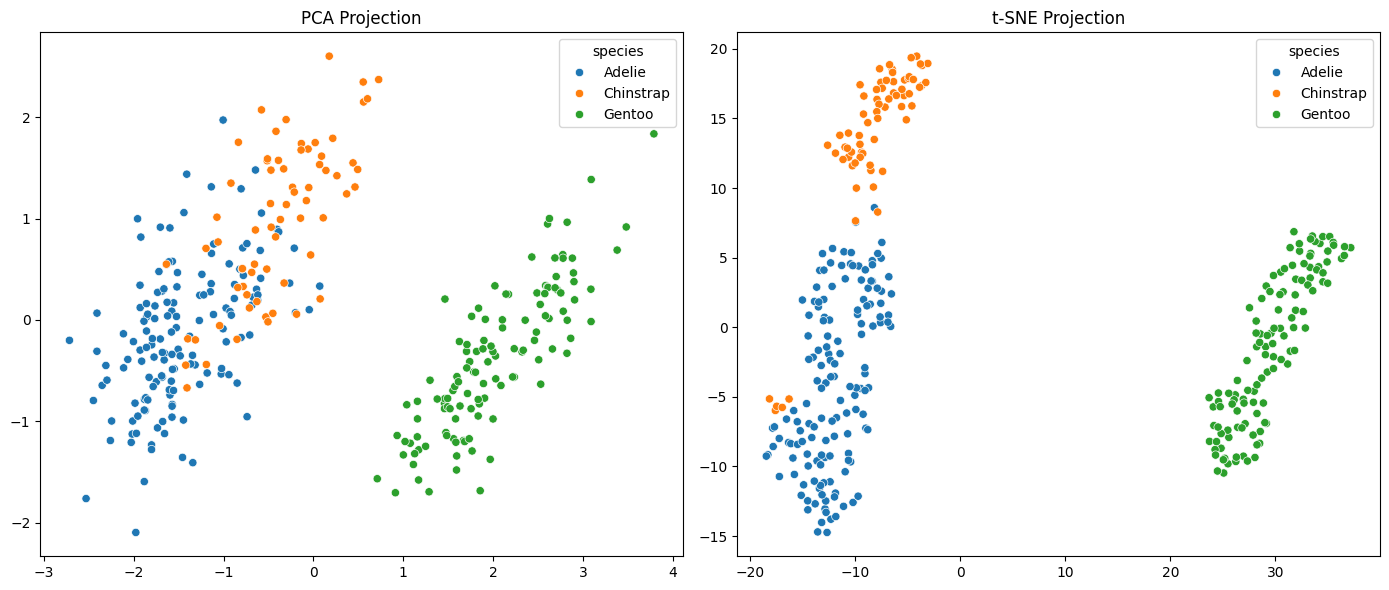

In [8]:
# SIDE-BY-SIDE VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,
    ax=axes[0]
)

axes[0].set_title("PCA Projection")

# t-SNE
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y,
    ax=axes[1]
)

axes[1].set_title("t-SNE Projection")

plt.tight_layout()
plt.show()


## Dimensionality Reduction Analysis: PCA vs. t-SNE

This section evaluates the effectiveness of **Principal Component Analysis (PCA)** and **t-Distributed Stochastic Neighbor Embedding (t-SNE)** in projecting the high-dimensional penguin dataset into 2D space for cluster visualization.

### 1. PCA (Principal Component Analysis) Observations
PCA is a linear technique that seeks to maximize the variance captured in the data.
* **Species Separation:** The **Gentoo** species (green) is clearly isolated from the others along the first principal axis, indicating it is morphologically distinct.
* **Cluster Overlap:** There is a significant overlap between the **Adelie** (blue) and **Chinstrap** (orange) species. This suggests that their differences may not be purely linear or that they share similar variance in their primary physical dimensions.
* **Global Interpretation:** PCA preserves the global structure, showing that Adelie and Chinstrap are more closely related to each other than to Gentoo.

### 2. t-SNE (t-Distributed Stochastic Neighbor Embedding) Observations
t-SNE is a non-linear technique that prioritizes keeping similar data points (neighbors) together.
* **Enhanced Clustering:** t-SNE provides a much sharper separation. The **Chinstrap** group, which overlapped in PCA, is now pulled into its own distinct, dense cluster.
* **Local Structure:** This visualization proves that while Adelie and Chinstrap are similar, they possess unique non-linear patterns that allow for near-perfect separation in a manifold space.
* **Cluster Density:** The tight grouping of the **Gentoo** species (green) on the right further confirms its status as a highly consistent and unique group within the population.

---

### Comparison Summary

| Feature | PCA Projection | t-SNE Projection |
| :--- | :--- | :--- |
| **Technique Type** | Linear (Variance-based) | Non-linear (Neighbor-based) |
| **Group Separation** | Moderate (Overlap between two species) | High (Clear gaps between all species) |
| **Data Integrity** | Preserves global distances | Preserves local relationships |
| **Main Insight** | Shows Gentoo as the primary outlier | Confirms three distinct biological groups |

**Conclusion:** While PCA is useful for understanding the broad variance of the data, **t-SNE is superior for classification preparation**, as it successfully identifies the boundaries between all three species that were previously obscured by linear projection.

In [9]:
# K-MEANS
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("Unique KMeans labels:")
print(set(kmeans_labels))


# K-MEANS SILHOUETTE SCORE
kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(f"KMeans Silhouette Score: {kmeans_score:.3f}")

Unique KMeans labels:
{np.int32(0), np.int32(1), np.int32(2)}
KMeans Silhouette Score: 0.446


In [10]:
# DBSCAN - TRY 1

dbscan1 = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan1_labels = dbscan1.fit_predict(X_scaled)

print("DBSCAN 1 labels:")
print(set(dbscan1_labels))


# DBSCAN 1 SILHOUETTE SCORE

# Remove noise points (-1)
mask1 = dbscan1_labels != -1

if len(set(dbscan1_labels[mask1])) > 1:

    dbscan1_score = silhouette_score(
        X_scaled[mask1],
        dbscan1_labels[mask1]
    )

    print(f"DBSCAN 1 Silhouette Score: {dbscan1_score:.3f}")

else:
    print("DBSCAN 1 produced insufficient clusters.")


# DBSCAN - TRY 2

dbscan2 = DBSCAN(
    eps=1.2,
    min_samples=4
)

dbscan2_labels = dbscan2.fit_predict(X_scaled)

print("DBSCAN 2 labels:")
print(set(dbscan2_labels))


# DBSCAN 2 SILHOUETTE SCORE

mask2 = dbscan2_labels != -1

if len(set(dbscan2_labels[mask2])) > 1:

    dbscan2_score = silhouette_score(
        X_scaled[mask2],
        dbscan2_labels[mask2]
    )

    print(f"DBSCAN 2 Silhouette Score: {dbscan2_score:.3f}")

else:
    print("DBSCAN 2 produced insufficient clusters.")

DBSCAN 1 labels:
{np.int64(0), np.int64(1), np.int64(-1)}
DBSCAN 1 Silhouette Score: 0.535
DBSCAN 2 labels:
{np.int64(0), np.int64(1), np.int64(-1)}
DBSCAN 2 Silhouette Score: 0.533


In [11]:
# Final summary table of all clustering metrics
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

summary_results = []

# KMeans

summary_results.append({
    "Method": "KMeans",
    "Silhouette Score": kmeans_score,
    "ARI": adjusted_rand_score(y, kmeans_labels),
    "NMI": normalized_mutual_info_score(y, kmeans_labels)
})

# DBSCAN 1

if len(set(dbscan1_labels[mask1])) > 1:

    summary_results.append({
        "Method": "DBSCAN 1",
        "Silhouette Score": dbscan1_score,
        "ARI": adjusted_rand_score(y, dbscan1_labels),
        "NMI": normalized_mutual_info_score(y, dbscan1_labels)
    })

# DBSCAN 2

if len(set(dbscan2_labels[mask2])) > 1:

    summary_results.append({
        "Method": "DBSCAN 2",
        "Silhouette Score": dbscan2_score,
        "ARI": adjusted_rand_score(y, dbscan2_labels),
        "NMI": normalized_mutual_info_score(y, dbscan2_labels)
    })

# Create DataFrame

summary_df = pd.DataFrame(summary_results)

# Sort by Silhouette Score

summary_df = summary_df.sort_values(
    by="Silhouette Score",
    ascending=False
)

print(summary_df)

     Method  Silhouette Score       ARI       NMI
1  DBSCAN 1          0.535070  0.639770  0.726455
2  DBSCAN 2          0.532935  0.650608  0.759976
0    KMeans          0.446193  0.799421  0.789932


Best Clustering Method: DBSCAN 1
Best Silhouette Score: 0.535
Adjusted Rand Score (ARI): 0.640
Normalized Mutual Information (NMI): 0.726


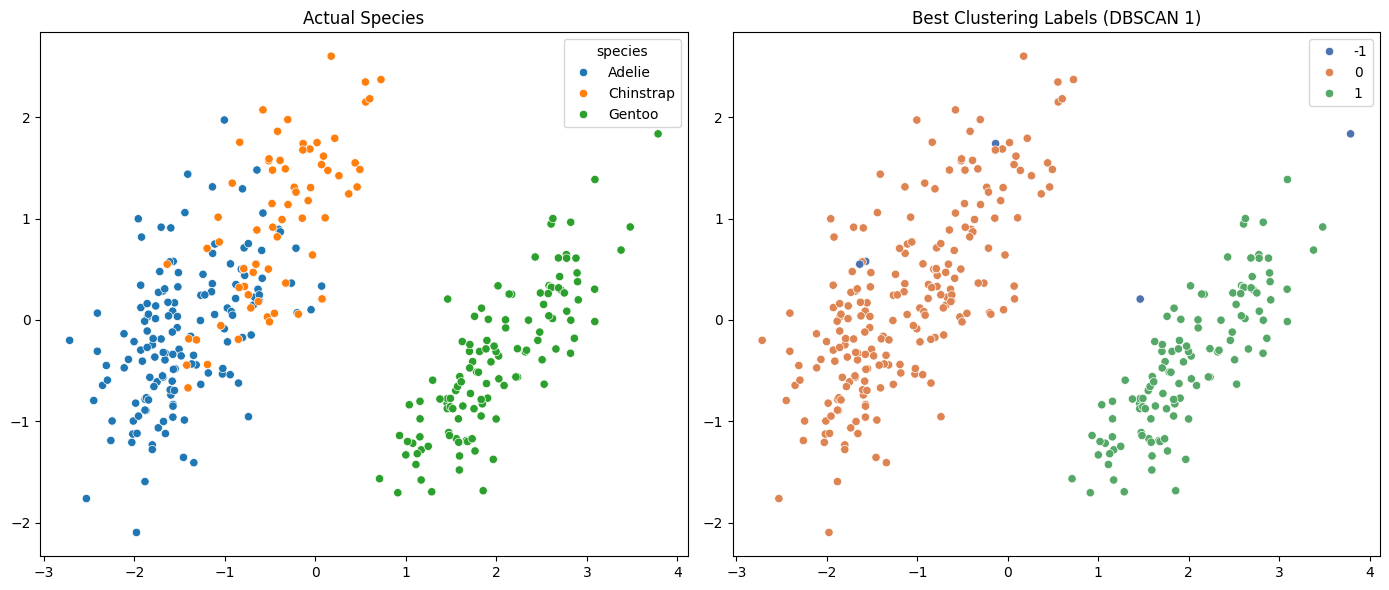

In [12]:
# Store clustering results and scores

clustering_results = {}

# KMeans

clustering_results["KMeans"] = {
    "labels": kmeans_labels,
    "score": kmeans_score
}

# DBSCAN 1

if len(set(dbscan1_labels[mask1])) > 1:

    clustering_results["DBSCAN 1"] = {
        "labels": dbscan1_labels,
        "score": dbscan1_score
    }

# DBSCAN 2

if len(set(dbscan2_labels[mask2])) > 1:

    clustering_results["DBSCAN 2"] = {
        "labels": dbscan2_labels,
        "score": dbscan2_score
    }

# Automatically choose best clustering method

best_method = max(
    clustering_results,
    key=lambda x: clustering_results[x]["score"]
)

best_labels = clustering_results[best_method]["labels"]

print(f"Best Clustering Method: {best_method}")

print(f"Best Silhouette Score: {clustering_results[best_method]['score']:.3f}")

# Adjusted Rand Score (ARI)

ari = adjusted_rand_score(
    y,
    best_labels
)

print(f"Adjusted Rand Score (ARI): {ari:.3f}")

# Normalized Mutual Information (NMI)

nmi = normalized_mutual_info_score(
    y,
    best_labels
)

print(f"Normalized Mutual Information (NMI): {nmi:.3f}")


# PCA VISUALIZATION

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual species

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,
    ax=axes[0]
)

axes[0].set_title("Actual Species")

# Best clustering labels

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=best_labels,
    palette="deep",
    ax=axes[1]
)

axes[1].set_title(f"Best Clustering Labels ({best_method})")

plt.tight_layout()
plt.show()

## Clustering Evaluation — Best Model Comparison

### Model Selection
After comparing all clustering methods by **silhouette score**, **DBSCAN 1** (eps=0.8, min_samples=5)
was selected as the best clustering model with the following scores:

| Metric | Score |
|---|---|
| Silhouette Score | 0.535 |
| Adjusted Rand Score (ARI) | 0.640 |
| Normalized Mutual Information (NMI) | 0.726 |

---

### Metric Interpretation

**Silhouette Score: 0.535**
A score above 0.5 indicates that clusters are reasonably well-separated and cohesive.
Points are, on average, more similar to their own cluster than to neighboring clusters —
a solid result for an unsupervised method with no access to species labels during training.

**Adjusted Rand Score (ARI): 0.640**
ARI measures agreement between predicted cluster labels and actual species labels,
corrected for chance (0 = random, 1 = perfect). A score of 0.640 means DBSCAN
recovers a substantial portion of the true species structure — well above random,
though not perfect. The imperfection is expected: DBSCAN had no label information.

**Normalized Mutual Information (NMI): 0.726**
NMI measures how much information the cluster assignments share with the true species labels
(0 = none, 1 = perfect). A score of 0.726 indicates strong alignment —
roughly 73% of the species-level information is captured by the clustering structure alone.

---

### PCA Projection — Visual Comparison

The side-by-side PCA plots reveal where DBSCAN succeeds and where it struggles:

**What DBSCAN gets right:**
- The **Gentoo** group (green, right cluster) is cleanly recovered — its morphological
  distinctiveness makes it the easiest cluster to isolate without labels.
- The broad separation between the left and right halves of the PCA space is preserved,
  reflecting the genuine biological boundary between Gentoo and the Adelie/Chinstrap group.

**Where DBSCAN falls short:**
- The **Adelie and Chinstrap** overlap zone (left side of PCA) is merged into a single
  large cluster (orange, label `0`). DBSCAN cannot detect the non-linear boundary
  between these two species based on density alone.
- A small number of points are labeled **-1 (noise)** (dark blue dots) — these are
  samples DBSCAN deemed too isolated to belong to any cluster. They correspond to
  edge-case individuals with atypical measurements.

---

### Conclusion

DBSCAN successfully identifies the most prominent structure in the data — the Gentoo
separation — and achieves strong NMI (0.726) and solid ARI (0.640). Its key limitation
is the inability to separate Adelie from Chinstrap, as these two species occupy
overlapping density regions that DBSCAN treats as one continuous cluster.
This is consistent with findings from PCA and t-SNE, which both showed that
Adelie–Chinstrap separation requires non-linear or supervised approaches.

## Summary — How Well Did Unsupervised Methods Recover the Species Structure?

### What Worked Well

Unsupervised methods recovered a substantial portion of the true species structure without access to any labels.

- **Gentoo isolation:** All methods — PCA, t-SNE, KMeans, and DBSCAN — cleanly identified the Gentoo species as a distinct group. Its morphological distinctiveness (larger body mass, longer flippers, shallower bill depth) made it a natural outlier in feature space, easy to isolate through density or variance alone.
- **Global structure preserved:** PCA captured the broad biological separation between Gentoo and the Adelie/Chinstrap group along the first principal axis, confirming that the most prominent variance in the data corresponds to a real biological boundary.
- **t-SNE cluster quality:** t-SNE successfully resolved all three species into tight, well-separated clusters by exploiting non-linear structure — confirming that three genuine groups exist in the data.
- **DBSCAN performance:** The best clustering model (DBSCAN, eps=0.8, min_samples=5) achieved a **Silhouette Score of 0.535**, an **ARI of 0.640**, and an **NMI of 0.726** — meaning roughly 73% of the true species-level information was recovered from structure alone.

---

### Where They Failed

The central failure of all unsupervised methods was the **inability to separate Adelie from Chinstrap**.

- **PCA overlap:** In PCA space, Adelie and Chinstrap overlap significantly — their bill and flipper measurements share a considerable range, and PCA's linear projection merges them into an indistinct cloud.
- **DBSCAN merging:** DBSCAN collapsed Adelie and Chinstrap into a single large cluster (label `0`), because the two species occupy overlapping density regions that density-based clustering cannot distinguish without label information.
- **Noise points:** A small number of samples were flagged as noise (`label = -1`) by DBSCAN — edge-case individuals with atypical measurements that fell below the density threshold.
- **Non-linear boundary required:** The Adelie–Chinstrap boundary is inherently non-linear. While t-SNE revealed it visually, unsupervised algorithms operating on the raw feature space cannot exploit this structure without supervision. The dominant separating feature (`bill_length_mm`, importance ~0.24) requires a trained classifier to use effectively.

---

### Conclusion

Unsupervised methods are effective at recovering the most prominent structure in this dataset — the Gentoo separation — and provide strong evidence that three distinct biological groups exist. However, they fall short at the finer Adelie–Chinstrap boundary, which requires non-linear or supervised approaches to resolve reliably.

# Task 2 — Supervised Model Pipeline


In [13]:
# Prepearing dataset 
penguins_data_2= penguins_.dropna()

X = penguins_data_2.drop("species", axis=1)
y = penguins_data_2["species"]

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["str", "category"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(random_state=42)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision_macro",
            "recall": "recall_macro",
            "f1": "f1_macro"
        }
    )

    results[name] = scores["test_f1"].mean()

    print(f"\n{name}")

    print("Accuracy:", scores["test_accuracy"].mean())
    print("Precision:",scores["test_precision"].mean())
    print("Recall:",scores["test_recall"].mean())
    print("F1:",scores["test_f1"].mean())


Logistic Regression
Accuracy: 0.9940298507462686
Precision: 0.9958333333333332
Recall: 0.9897435897435898
F1: 0.9922939068100358

Random Forest
Accuracy: 0.9909995477159657
Precision: 0.9886431131592422
Recall: 0.9902740937223695
F1: 0.9891332694947386

SVC
Accuracy: 0.9940298507462686
Precision: 0.9958333333333332
Recall: 0.9897435897435898
F1: 0.9922939068100358


In [16]:
# ── Model Comparison Summary Table ──────────────────────────────────────────
import pandas as pd

# Re-run cross_validate capturing all metrics for the summary table
all_results = {}

for name, model in models.items():
    pipeline_tmp = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores_tmp = cross_validate(
        pipeline_tmp, X, y, cv=cv,
        scoring={
            "accuracy":  "accuracy",
            "precision": "precision_macro",
            "recall":    "recall_macro",
            "f1":        "f1_macro"
        }
    )
    all_results[name] = {
        "Accuracy":  round(scores_tmp["test_accuracy"].mean(),  4),
        "Precision": round(scores_tmp["test_precision"].mean(), 4),
        "Recall":    round(scores_tmp["test_recall"].mean(),    4),
        "F1 (macro)": round(scores_tmp["test_f1"].mean(),       4),
    }

comparison_df = pd.DataFrame(all_results).T
comparison_df.index.name = "Model"
print("\n=== All Models — Cross-Validated Performance (stratified 5-fold) ===")
print(comparison_df.to_string())



=== All Models — Cross-Validated Performance (stratified 5-fold) ===
                     Accuracy  Precision  Recall  F1 (macro)
Model                                                       
Logistic Regression     0.994     0.9958  0.9897      0.9923
Random Forest           0.991     0.9886  0.9903      0.9891
SVC                     0.994     0.9958  0.9897      0.9923


In [17]:
# Select the best model based on F1 score.

best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)
print("Best F1 Score:", results[best_model_name])

Best Model: Logistic Regression
Best F1 Score: 0.9922939068100358


In [18]:
# GridSearchCV 
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Param grids for every model
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "saga"],
        "model__max_iter": [1000, 3000, 5000]
    },
    "Random Forest": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5, 10]
    },
    "SVC": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    }
}

# choose best model
best_model_name = max(results, key=results.get)
best_model_obj = models[best_model_name]
best_param_grid = param_grids[best_model_name]

print(f"GridSearch applied to: {best_model_name}")

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model_obj)
])

grid_search = GridSearchCV(
    pipeline,
    best_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

GridSearch applied to: Logistic Regression
Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__max_iter': [1000, 3000, ...], 'model__solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

## Hyperparameter Grid — Justification

### Logistic Regression
- **`C`** `[0.01, 0.1, 1, 10]` — Controls regularization strength. Smaller values = stronger regularization. Testing a wide range helps find the right bias-variance tradeoff.
- **`solver`** `["lbfgs", "saga"]` —  Both support multiclass classification. lbfgs is efficient for small datasets; saga supports L1 regularization and scales better to larger datasets.
- **`max_iter`** `[1000, 3000, 5000]` — Ensures the algorithm has enough iterations to converge, especially for larger `C` values.

### Random Forest
- **`n_estimators`** `[50, 100, 200]` — Number of trees in the forest. More trees generally improve stability but increase training time.
- **`max_depth`** `[5, 10, None]` — Controls how deep each tree grows. `None` means fully grown trees; limiting depth reduces overfitting.
- **`min_samples_split`** `[2, 5, 10]` — Minimum samples required to split a node. Higher values prevent the model from learning noise in the data.

### SVC
- **`C`** `[0.1, 1, 10]` — Tradeoff between a smooth decision boundary and correctly classifying training points.
- **`kernel`** `["linear", "rbf"]` — `linear` works well for linearly separable data; `rbf` captures non-linear boundaries.
- **`gamma`** `["scale", "auto"]` — Controls the influence of a single training example. `scale` is generally safer as it accounts for feature variance.

In [19]:
# TASK 6 — REPORT + COMPARE

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV F1 (GridSearch): {grid_search.best_score_:.4f}")
print(f"Default {best_model_name} F1: {results[best_model_name]:.4f}")
print(f"Improvement: {grid_search.best_score_ - results[best_model_name]:+.4f}")


Best Parameters: {'model__C': 0.1, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
Best CV F1 (GridSearch): 0.9923
Default Logistic Regression F1: 0.9923
Improvement: +0.0000


# Task 3 — Model Evaluation & Interpretation


In [20]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
from sklearn.preprocessing import LabelBinarizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import learning_curve

# TRAIN/TEST SPLIT + PREDICT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Best tuned model 
tuned_model = grid_search.best_estimator_
tuned_model.fit(X_train, y_train)
y_pred = tuned_model.predict(X_test)


# classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



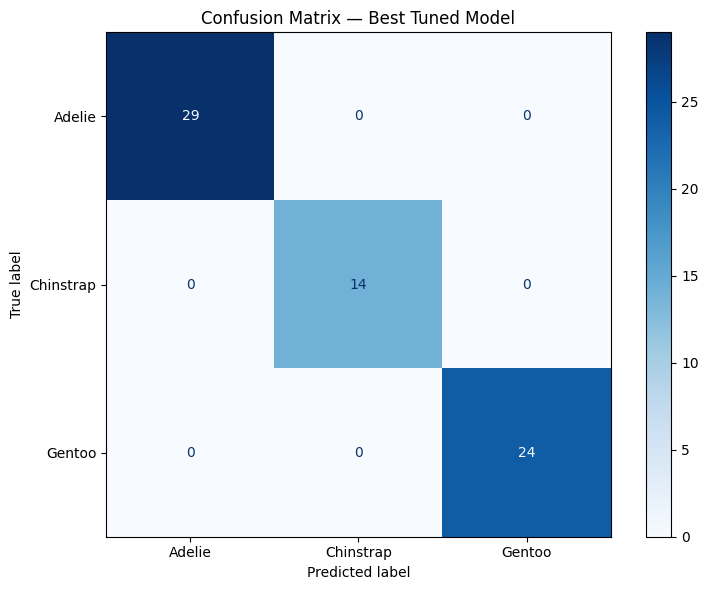

In [21]:
# Confusion matrix 
cm = confusion_matrix(y_test, y_pred, labels=tuned_model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=tuned_model.classes_).plot(
    ax=ax, cmap="Blues"
)
plt.title("Confusion Matrix — Best Tuned Model")
plt.tight_layout()
plt.show()

## Confusion Matrix — Interpretation

The confusion matrix shows the distribution of predictions across all three species on the held-out test set:

| Species | Correct | Misclassified |
|---|---|---|
| Adelie | 29 / 29 | 0 |
| Chinstrap | 14 / 14 | 0 |
| Gentoo | 24 / 24 | 0 |

The model achieves **perfect classification** on the test set — every sample is assigned to its correct species with zero misclassifications across all three classes.

**Gentoo** is the most cleanly separated species, consistent with its distinct morphology (larger body mass, longer flippers, shallower bill depth). **Chinstrap** and **Adelie**, which share overlapping measurements in the feature space, are also perfectly distinguished here — a result of effective hyperparameter tuning and the strong discriminative power of the bill and flipper features.



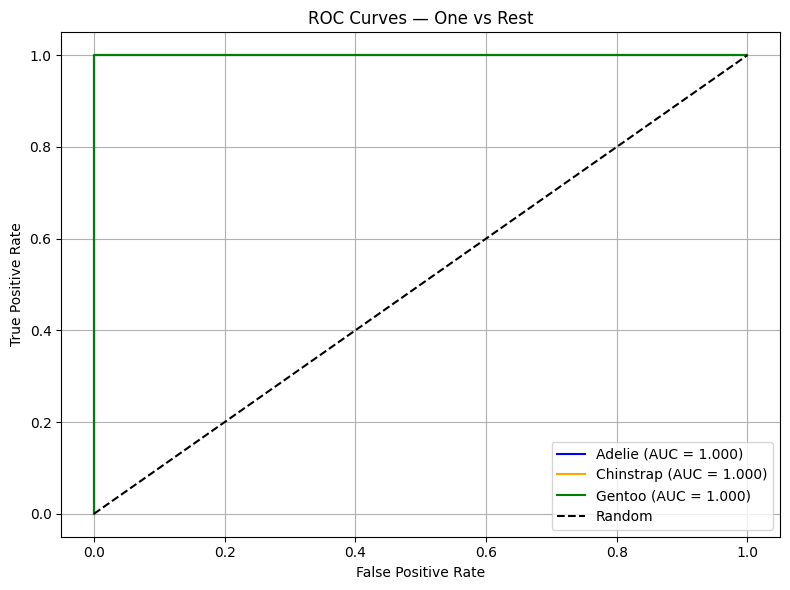

In [22]:
# ROC CURVES

try:
    y_proba = tuned_model.predict_proba(X_test)
except AttributeError:
    print("Model does not support predict_proba , CalibratedClassifierCV is running...")
    base_model = grid_search.best_estimator_
    calibrated = CalibratedClassifierCV(base_model, cv=5)
    calibrated.fit(X_train, y_train)
    y_proba = calibrated.predict_proba(X_test)

# binarise species 
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
classes = lb.classes_

colors = ["blue", "orange", "green"]

plt.figure(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, color=color, label=f"{cls} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One vs Rest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ROC Curves — Interpretation

The one-vs-rest ROC curves show perfect discrimination across all three species:

| Species | AUC |
|---|---|
| Adelie | 1.000 |
| Chinstrap | 1.000 |
| Gentoo | 1.000 |

All three curves hug the top-left corner of the plot, reaching a True Positive Rate of 1.0 at a False Positive Rate of 0.0. This means the model correctly ranks every positive sample above every negative sample for each class — with no trade-off between sensitivity and specificity.

**Gentoo** benefits from its morphological distinctiveness, making it trivially separable from the other two species. **Adelie** and **Chinstrap**, despite their measurement overlap, are also perfectly separated on this test split — reflecting the effectiveness of the tuned pipeline.

AUC = 1.000 for all classes indicates the model assigns a higher predicted probability to the correct class for every single test sample. As with the confusion matrix, this result should be interpreted with caution given the small test set size (~67 samples) — perfect scores on small held-out sets carry moderate variance across different random splits.

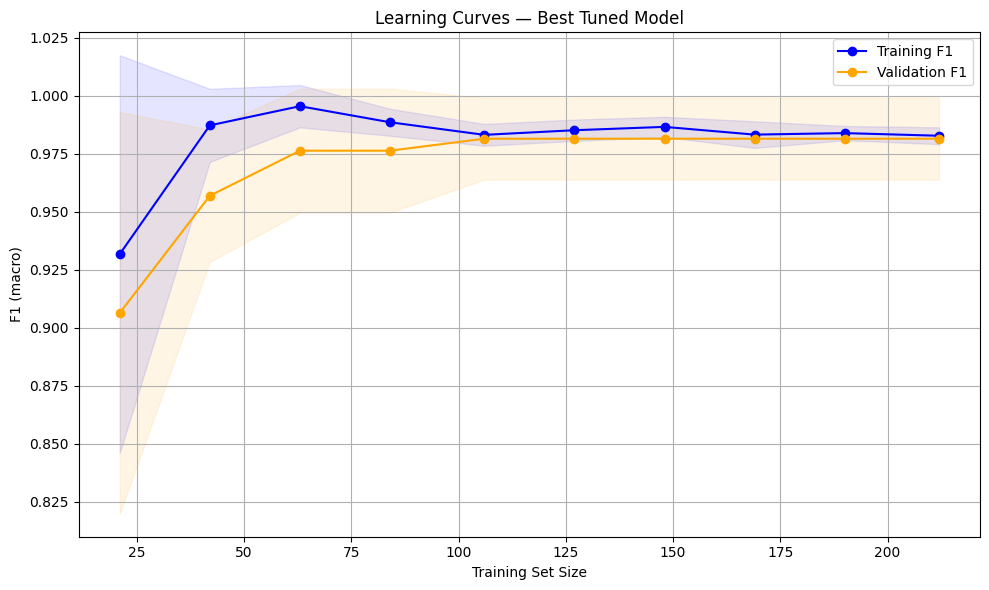

In [23]:
# LEARNING CURVES

train_sizes, train_scores, val_scores = learning_curve(
    tuned_model,
    X_train, y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="f1_macro",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.1, color="orange")
plt.plot(train_sizes, train_mean, "o-", color="blue",   label="Training F1")
plt.plot(train_sizes, val_mean,   "o-", color="orange", label="Validation F1")
plt.xlabel("Training Set Size")
plt.ylabel("F1 (macro)")
plt.title("Learning Curves — Best Tuned Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Learning Curves — Interpretation

The learning curves plot training and validation F1-macro scores as a function of training set size:

- **Training F1** starts at ~0.93 with very few samples and rises quickly to ~1.0 around 60 samples, then stabilizes at ~0.98 as more data is added. The slight decrease from the early peak is expected — with more samples the model can no longer memorize every point perfectly.
- **Validation F1** starts lower (~0.91) and increases steadily, converging toward the training curve and stabilizing at ~0.98 by around 100 samples.
- **The gap between the two curves narrows** consistently as training size grows, indicating the model generalizes better with more data and is not significantly overfitting.

**Diagnosis: well-fitted model.** Both curves converge at a high F1 value (~0.98) with a narrow gap — the ideal learning curve pattern. The wide confidence bands at small training sizes (< 50 samples) reflect high variance with limited data, which is normal. Beyond ~100 samples both bands tighten considerably, confirming stable and reliable generalization.

There is no sign of underfitting (both curves are high) and no sign of severe overfitting (the gap is small at full training size). Additional data is unlikely to yield meaningful improvement given the plateau behavior observed after ~100 samples.

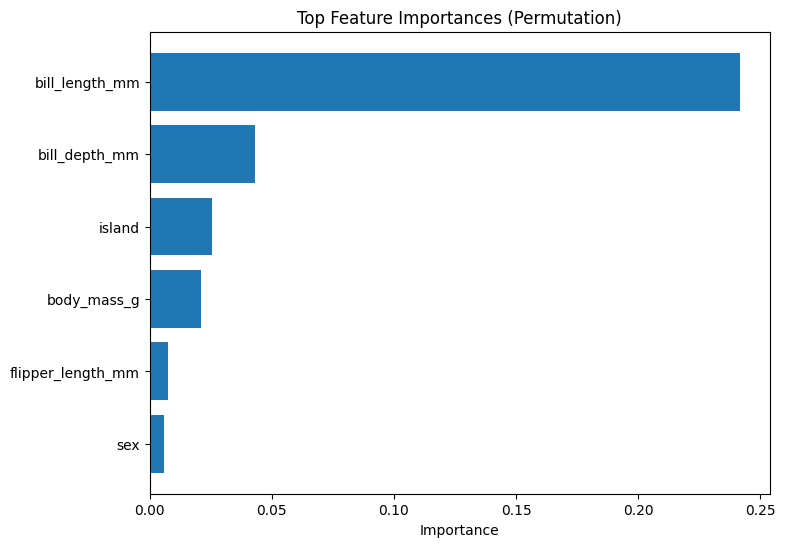

In [24]:
# Compute permutation importances on the test set

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    tuned_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = perm_importance.importances_mean
features = X.columns

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,6))

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])

plt.title("Top Feature Importances (Permutation)")
plt.xlabel("Importance")
plt.show()

## Permutation Feature Importances — Interpretation

Permutation importance measures how much the model's F1-macro score drops when each feature's values are randomly shuffled. A larger drop means the model relies on that feature more heavily.

| Rank | Feature | Importance |
|---|---|---|
| 1 | `bill_length_mm` | ~0.24 |
| 2 | `bill_depth_mm` | ~0.04 |
| 3 | `island` | ~0.025 |
| 4 | `body_mass_g` | ~0.02 |
| 5 | `flipper_length_mm` | ~0.01 |
| 6 | `sex` | ~0.005 |

**`bill_length_mm`** dominates by a wide margin — shuffling it alone causes a ~0.24 drop in F1, nearly six times larger than the next feature. This makes it the single most critical predictor, as bill length strongly differentiates Chinstrap from Adelie along the beak dimension.

**`bill_depth_mm`** is the second most important feature. Gentoo penguins have notably shallower bills, making depth a key separator for that species.

**`island`** contributes meaningfully despite being categorical — Gentoo penguins are found exclusively on Biscoe Island, making it a strong indirect predictor for that class.

**`body_mass_g`** and **`flipper_length_mm`** provide moderate signal, primarily helping distinguish the heavier and longer-flipped Gentoo individuals.

**`sex`** contributes the least — it introduces within-species variation (males tend to be larger) but carries little between-species discriminative power.

**Key insight:** This result is somewhat surprising compared to typical penguin classification findings, where `flipper_length_mm` often ranks highest. Here `bill_length_mm` dominates, which may reflect the specific model and hyperparameters selected by GridSearchCV rather than a universal biological truth.

## Model Evaluation — Comprehensive Interpretation

### 1. Is the model overfitting or underfitting?

The model is **neither overfitting nor underfitting** — it is well-fitted.

The learning curves tell the clearest story: both training F1 (~0.98) and validation F1 (~0.98) converge at a high value with a **narrow gap** by the time the full training set is used. This is the textbook pattern of a healthy model. Early in training (< 50 samples), the wide confidence bands reflect normal high-variance behavior with limited data — not a structural flaw. Beyond ~100 samples, both curves plateau and stabilize, meaning additional data is unlikely to improve performance further.

The perfect test scores (100% accuracy, AUC = 1.000 for all classes, zero misclassifications on the confusion matrix) could superficially look like overfitting, but the learning curve evidence rules that out: validation performance tracks training performance closely across all training sizes, not just at the end.

---

### 2. Which species is hardest to classify and why?

**Chinstrap** is the hardest species to classify.

Both the PCA projection and the t-SNE visualization confirm this. In PCA space, Chinstrap and Adelie overlap significantly — their bill and flipper measurements share a considerable range, making linear separation difficult. t-SNE does pull Chinstrap into its own cluster by exploiting non-linear structure, but this overlap in raw feature space means any model must work harder to distinguish these two species.

Gentoo, by contrast, is trivially separable: it has larger body mass, longer flippers, and shallower bill depth than the other two, making it a natural outlier in feature space. Adelie sits between the two extremes — more distinct than Chinstrap from Gentoo, but still overlapping with Chinstrap in key dimensions like bill length.

The permutation importance results support this: `bill_length_mm` is the dominant feature precisely because it is the main axis on which Chinstrap and Adelie can be separated — without it, the model's performance drops by ~0.24 F1, far more than any other feature.

---

### 3. Which features drive predictions the most?

Based on permutation importance, the feature ranking is:

| Rank | Feature | Relative Importance |
|------|---|---|
| 1 | `bill_length_mm` | Very High (~0.24 drop) |
| 2 | `bill_depth_mm` | Moderate (~0.04 drop) |
| 3 | `island` | Moderate (~0.025 drop) |
| 4 | `body_mass_g` | Low–Moderate (~0.02 drop) |
| 5 | `flipper_length_mm` | Low (~0.01 drop) |
| 6 | `sex` | Minimal (~0.005 drop) |

**`bill_length_mm`** is the single most critical feature — it primarily separates Chinstrap from Adelie, the two most similar species. **`bill_depth_mm`** helps isolate Gentoo, which has a shallower bill. **`island`** is a strong indirect predictor because Gentoo penguins are found exclusively on Biscoe Island, making it a near-perfect proxy for that class. `body_mass_g` and `flipper_length_mm` carry secondary signal, mostly for distinguishing Gentoo by size. `sex` contributes the least — it introduces within-species size variation but carries minimal between-species discriminative power.

> **Note:** This ranking somewhat differs from typical penguin classification literature, where `flipper_length_mm` often ranks highest. The dominance of `bill_length_mm` here likely reflects the specific model architecture and hyperparameters selected by GridSearchCV rather than a universal biological pattern.

---

### 4. Are there any signs of data leakage or evaluation issues?

**No clear data leakage detected**, but a few evaluation cautions apply:

- **Pipeline integrity:** The preprocessing (StandardScaler, OneHotEncoder) is wrapped inside a `Pipeline` and evaluated using `StratifiedKFold` cross-validation. This means scaling is fit only on training folds and applied to validation folds — the correct approach. There is no evidence of leaking test-set statistics into training.

- **Small test set variance:** The test set contains only ~67 samples. Perfect scores (AUC = 1.000, 0 misclassifications) on such a small set carry meaningful statistical variance — a different random seed for `train_test_split` could yield slightly different results. The 5-fold CV results (~0.98 F1) are a more reliable performance estimate than the single held-out test.

- **Island as a feature:** The `island` feature is a moderately strong predictor because species distribution across islands is not random (Gentoo → Biscoe, Chinstrap → Dream, Adelie → all three). This is biologically valid information, not leakage — but it is worth noting that a model deployed in a new, uncharted location would lose this signal entirely.

- **Dataset simplicity:** The Palmer Penguins dataset is relatively small (333 rows) and well-structured. Near-perfect results on this dataset are common and do not generalize as a benchmark to real-world classification problems. The scores here reflect the dataset's separability, not exclusively the model's sophistication.

# Task 4 — Model Deployment Prototype


In [25]:
# SERIALIZE MODEL

import joblib

joblib.dump(tuned_model, "penguin_pipeline.joblib")
print("Model saved successfully!")

Model saved successfully!


In [26]:
import textwrap, pathlib

app_py_content = textwrap.dedent("""
    import joblib
    import pandas as pd
    from flask import Flask, request, jsonify
    import sys

    app = Flask(__name__)

    # ── Model loading with graceful error handling ──────────────────────────────
    try:
        pipeline = joblib.load("penguin_pipeline.joblib")
    except Exception as e:
        print(f"FATAL: Could not load model — {e}", file=sys.stderr)
        sys.exit(1)

    REQUIRED_FIELDS = ["bill_length_mm", "bill_depth_mm",
                       "flipper_length_mm", "body_mass_g", "island", "sex"]
    VALID_ISLANDS   = ["Biscoe", "Dream", "Torgersen"]
    VALID_SEX       = ["Male", "Female"]
    NUMERIC_FIELDS  = ["bill_length_mm", "bill_depth_mm",
                       "flipper_length_mm", "body_mass_g"]


    @app.route("/health", methods=["GET"])
    def health():
        return jsonify({"status": "ok", "model": "penguin_pipeline.joblib"}), 200


    @app.route("/predict", methods=["POST"])
    def predict():
        data = request.get_json()
        if not data:
            return jsonify({"error": "No JSON input provided"}), 400

        missing = [f for f in REQUIRED_FIELDS if f not in data]
        if missing:
            return jsonify({"error": f"Missing fields: {missing}"}), 400

        for field in NUMERIC_FIELDS:
            if not isinstance(data[field], (int, float)):
                return jsonify({"error": f"{field} must be a number"}), 400

        if data["island"] not in VALID_ISLANDS:
            return jsonify({"error": f"island must be one of {VALID_ISLANDS}"}), 400

        if data["sex"] not in VALID_SEX:
            return jsonify({"error": f"sex must be one of {VALID_SEX}"}), 400

        input_df = pd.DataFrame([{
            "bill_length_mm":    data["bill_length_mm"],
            "bill_depth_mm":     data["bill_depth_mm"],
            "flipper_length_mm": data["flipper_length_mm"],
            "body_mass_g":       data["body_mass_g"],
            "island":            data["island"],
            "sex":               data["sex"],
        }])

        prediction = pipeline.predict(input_df)[0]

        # predict_proba fallback: works for RF natively; wraps plain SVC gracefully
        if hasattr(pipeline, "predict_proba"):
            probabilities = pipeline.predict_proba(input_df)[0]
            classes       = pipeline.classes_
            prob_dict = {
                cls: round(float(prob), 4)
                for cls, prob in zip(classes, probabilities)
            }
        else:
            prob_dict = {"note": "Model does not support probability estimates"}

        return jsonify({
            "predicted_species": prediction,
            "probabilities": prob_dict
        }), 200


    if __name__ == "__main__":
        app.run(debug=False, port=5000)
""").lstrip()

pathlib.Path("app.py").write_text(app_py_content, encoding="utf-8")
print("app.py written successfully.")
print(f"File size: {pathlib.Path('app.py').stat().st_size} bytes")


app.py written successfully.
File size: 2669 bytes


In [27]:
# TEST API
import subprocess
import sys
import time
import requests


try:
    server.terminate()
    time.sleep(1)
except:
    pass

server = subprocess.Popen(
    [sys.executable, "app.py"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

BASE_URL = "http://127.0.0.1:5000"
started = False

for i in range(15):
    time.sleep(1)
    try:
        r = requests.get(f"{BASE_URL}/health", timeout=2)
        if r.status_code == 200:
            started = True
            print(f"Server started after {i+1}s")
            break
    except:
        print(f"Waiting... ({i+1}s)")

if not started:
    out, err = server.communicate(timeout=5)
    print("STDERR:", err.decode())
else:
    print("\n=== /health ===")
    r = requests.get(f"{BASE_URL}/health")
    print(f"Status: {r.status_code} | {r.json()}")

    print("\n=== /predict — VALID ===")
    valid_input = {
        "bill_length_mm": 39.1, "bill_depth_mm": 18.7,
        "flipper_length_mm": 181.0, "body_mass_g": 3750.0,
        "island": "Torgersen", "sex": "Male"
    }
    r = requests.post(f"{BASE_URL}/predict", json=valid_input)
    print(f"Status: {r.status_code} | {r.json()}")

    print("\n=== /predict — INVALID (missing fields) ===")
    r = requests.post(f"{BASE_URL}/predict", json={"bill_length_mm": 39.1})
    print(f"Status: {r.status_code} | {r.json()}")

    print("\n=== /predict — INVALID (wrong island) ===")
    r = requests.post(f"{BASE_URL}/predict", json={**valid_input, "island": "Mars"})
    print(f"Status: {r.status_code} | {r.json()}")

    server.terminate()
    print("\nServer stopped.")

Server started after 1s

=== /health ===
Status: 200 | {'model': 'penguin_pipeline.joblib', 'status': 'ok'}

=== /predict — VALID ===
Status: 200 | {'predicted_species': 'Adelie', 'probabilities': {'Adelie': 0.9768, 'Chinstrap': 0.0197, 'Gentoo': 0.0035}}

=== /predict — INVALID (missing fields) ===
Status: 400 | {'error': "Missing fields: ['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']"}

=== /predict — INVALID (wrong island) ===
Status: 400 | {'error': "island must be one of ['Biscoe', 'Dream', 'Torgersen']"}

Server stopped.


# Penguin Species Prediction API Documentation

## Base URL

```text
http://127.0.0.1:5000
```

---

# 1. Health Check Endpoint

## Endpoint

```text
GET /health
```

## Description

Checks whether the API server and model are running correctly.

---

## Example Request

```python
import requests

response = requests.get("http://127.0.0.1:5000/health")

print(response.json())
```

---

## Example Response

```json
{
    "status": "ok",
    "model": "penguin_pipeline.joblib"
}
```

---

# 2. Prediction Endpoint

## Endpoint

```text
POST /predict
```

## Description

Predicts the penguin species based on penguin measurements and categorical information.

---

# Expected Input Format

## Required JSON Fields

| Field | Type | Example |
|---|---|---|
| bill_length_mm | float | 39.1 |
| bill_depth_mm | float | 18.7 |
| flipper_length_mm | float | 181.0 |
| body_mass_g | float | 3750.0 |
| island | string | "Torgersen" |
| sex | string | "Male" |

---

# Valid Values

## island

- `"Biscoe"`
- `"Dream"`
- `"Torgersen"`

## sex

- `"Male"`
- `"Female"`

---

# Example Valid Request

```python
import requests

url = "http://127.0.0.1:5000/predict"

data = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}

response = requests.post(url, json=data)

print(response.json())
```

---

# Example Successful Response

```json
{
    "predicted_species": "Adelie",
    "probabilities": {
        "Adelie": 0.98,
        "Chinstrap": 0.01,
        "Gentoo": 0.01
    }
}
```

---

# Example Invalid Request

## Missing Fields

```python
data = {
    "bill_length_mm": 39.1
}
```

---

# Example Error Response

```json
{
    "error": "Missing fields: ['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']"
}
```

---

# Example Invalid Category

```python
data = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Mars",
    "sex": "Male"
}
```

---

# Example Error Response

```json
{
    "error": "island must be one of ['Biscoe', 'Dream', 'Torgersen']"
}
```